# Task1 仿真平台调用引擎的有效性

## 参考运行结果

直接调用 QuTiP / QuantumOptics / QuantumToolbox 等软件的参考代码，不通过 qsim 的仿真平台。


In [1]:
import subprocess, json, sys
from pathlib import Path

REFERENCE_DIR = Path("task1\\native_references") 
JULIA_BIN = "julia"
JULIA_SYSIMG = Path("C:\\Users\\yijia\\.julia\\environments\\v1.12\\sysimage_quantum.dll")

def run_reference(cmd):
    return json.loads(subprocess.run(cmd, capture_output=True, text=True, encoding="utf-8", check=True).stdout)

res_refs = {}

res_refs["qutip"] = run_reference(
    [sys.executable, f"{REFERENCE_DIR}\\qutip_native.py"]
)
res_refs["qoptics"] = run_reference(
    [JULIA_BIN, "-J", JULIA_SYSIMG, f"{REFERENCE_DIR}\\qoptics_native.jl"]
)
res_refs["qtoolbox"] = run_reference(
    [JULIA_BIN, "-J", JULIA_SYSIMG, f"{REFERENCE_DIR}\\qtoolbox_native.jl"]
)


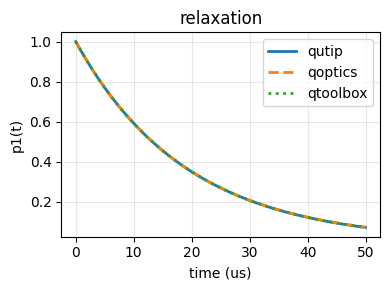

In [2]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(4, 3))
ax = plt.axes()

styles = ["-", "--", ":"]
case_name = "relaxation"

for (engine_name, payload), style in zip(res_refs.items(), styles):
    case = payload["cases"][case_name]
    ax.plot(
        case["times"], case["p1_t"], 
        label=engine_name, linewidth=2, linestyle=style,
    )

    ax.set_title(case_name)
    ax.set_xlabel("time (us)")
    ax.set_ylabel("p1(t)")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()


## qsim 多引擎仿真结果

创建一个 `model`，内含三个求解器（solver），可以从 `model.results` 中获取仿真结果，用 `solver_id` 标记求解器。


In [1]:
from qsim.workflow import create_model, DefaultAnalyserConfig
from pathlib import Path

TASK_DIR = Path("task1")

model = create_model(
    task_config   = f"{TASK_DIR}\\task.yaml",
    solver_config = {
        "qutip":    f"{TASK_DIR}\\qutip.yaml",
        "qoptics":  f"{TASK_DIR}\\qoptics.yaml",
        "qtoolbox": f"{TASK_DIR}\\qtoolbox.yaml",
    },
)

analysis_cfg = DefaultAnalyserConfig(metrics=['population'])
model.add_analyser('pop1', 'qutip',    analysis_cfg)
model.add_analyser('pop2', 'qoptics',  analysis_cfg)
model.add_analyser('pop3', 'qtoolbox', analysis_cfg)
model.run_all()
model.save()

WindowsPath('D:/超导量子计算机噪声抑制/qsim/examples/noise_simulation_tests/task1/runs')

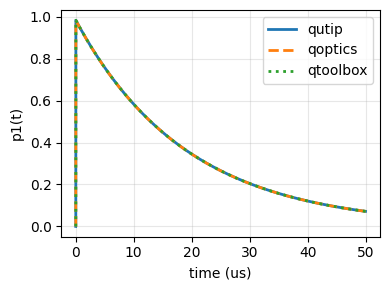

In [7]:
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(4, 3))
ax = plt.axes()

styles = ["-", "--", ":"]
ana_ids = ["pop1", "pop2", "pop3"]

for ana_id, style in zip(ana_ids, styles):
    analysis = model.get_analysis(analyser_id=ana_id)
    t = analysis.metrics['population']['times']
    pop = analysis.metrics['population']['values']
    ax.plot(
        1e6 * np.array(t), np.array(pop['1']),
        label=analysis.trajectory_id, 
        linewidth=2, linestyle=style
    )

    ax.set_xlabel("time (us)")
    ax.set_ylabel("p1(t)")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()
